In [66]:
#dataset for house loan prediction
import pandas as pd
data=pd.read_csv('/content/train_loan.csv')
df = pd.DataFrame(data)
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [67]:
df.isnull().sum()
# Total 614 rows are there
# 13 Null values in Gender
#  3 Null values in Married
# 15 Null values in Dependents .... so on

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [68]:
# drop field Self Employed
df.drop("Self_Employed",axis=1,inplace=True)

In [69]:
# NULL values replace by mode value
import statistics as st
df.loc[df["Gender"].isna(),"Gender"] = st.mode(df["Gender"])
df.loc[df["Dependents"].isna(),"Dependents"] = st.mode(df["Dependents"])
df.loc[df["LoanAmount"].isna(),"LoanAmount"] = st.mode(df["LoanAmount"])
df.loc[df["Loan_Amount_Term"].isna(),"Loan_Amount_Term"] = st.mode(df["Loan_Amount_Term"])
df.loc[df["Credit_History"].isna(),"Credit_History"] = st.mode(df["Credit_History"])


In [70]:
# Find outlier
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000
mean,5403.459283,1621.245798,145.465798,342.410423,0.855049
std,6109.041673,2926.248369,84.180967,64.428629,0.352339
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2877.500000,0.000000,100.250000,360.000000,1.000000
50%,3812.500000,1188.500000,125.000000,360.000000,1.000000
75%,5795.000000,2297.250000,164.750000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


<Axes: ylabel='ApplicantIncome'>

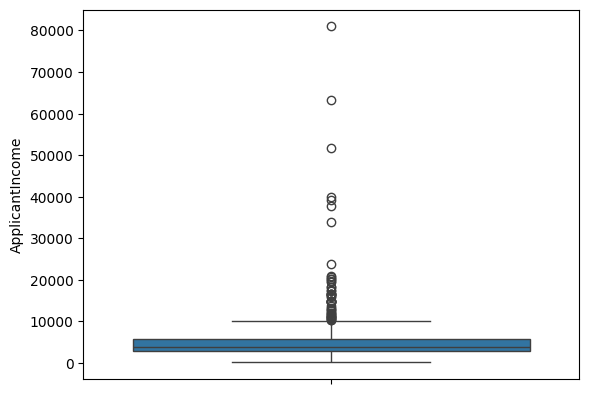

In [71]:
import seaborn as sns
sns.boxplot(df["ApplicantIncome"])
#outlier obtained for ApplicantIncome

<Axes: ylabel='LoanAmount'>

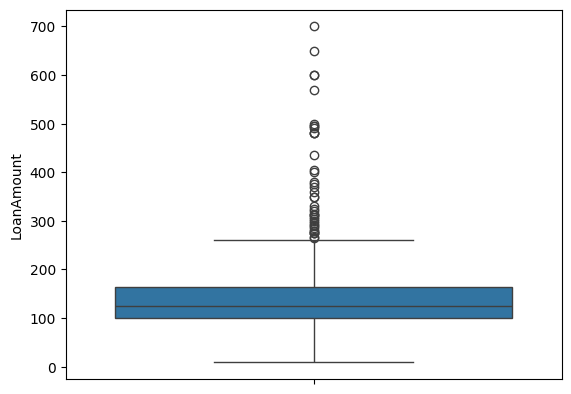

In [72]:
sns.boxplot(df["LoanAmount"])
#outlier obtained for ApplicantIncome

In [73]:
df

,Loan_ID,Gender,Married,Dependents,Education,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,5849,0.0,120.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,7583,0.0,187.0,360.0,1.0,Urban,Y


In [74]:
#oneHotEncoding done for Gender, Married, Education, Property_Area, Loan_Status
import pandas as pd
df_encoded = pd.get_dummies(df, columns=['Gender'],dtype=int,drop_first=True)
df_encoded = pd.get_dummies(df_encoded, columns=['Married'],dtype=int,drop_first=True)

df_encoded = pd.get_dummies(df_encoded, columns=['Education'],dtype=int,drop_first=True)
df_encoded = pd.get_dummies(df_encoded, columns=['Property_Area'],dtype=int,drop_first=True)
df_encoded = pd.get_dummies(df_encoded, columns=['Loan_Status'],dtype=int,drop_first=True)

# display the encoded data frame
df_encoded

,Loan_ID,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Education_Not Graduate,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Y
0,LP001002,0,5849,0.0,120.0,360.0,1.0,1,0,0,0,1,1
1,LP001003,1,4583,1508.0,128.0,360.0,1.0,1,1,0,0,0,0
2,LP001005,0,3000,0.0,66.0,360.0,1.0,1,1,0,0,1,1
3,LP001006,0,2583,2358.0,120.0,360.0,1.0,1,1,1,0,1,1
4,LP001008,0,6000,0.0,141.0,360.0,1.0,1,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,0,2900,0.0,71.0,360.0,1.0,0,0,0,0,0,1
610,LP002979,3+,4106,0.0,40.0,180.0,1.0,1,1,0,0,0,1
611,LP002983,1,8072,240.0,253.0,360.0,1.0,1,1,0,0,1,1
612,LP002984,2,7583,0.0,187.0,360.0,1.0,1,1,0,0,1,1


In [75]:
# drop the unique and Other columns
df_encoded.drop("Loan_ID",axis=1,inplace=True)
df_encoded.drop("Dependents",axis=1,inplace=True)
df_encoded.drop("Education_Not Graduate",axis=1,inplace=True)

In [76]:
# Start Scaling process
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


# Taking Significant Numerical columns for scaling
num_cols = ["ApplicantIncome", "CoapplicantIncome", "Loan_Amount_Term", "Credit_History", "Gender_Male","Married_Yes","Property_Area_Semiurban","Property_Area_Urban","Loan_Status_Y"]
scaler = StandardScaler()
# training the machine to the sample data ie scaler.fit
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

# Define X as features column and y as target column
X = df_encoded.drop("LoanAmount", axis=1)
y = df_encoded["LoanAmount"]

# split data into X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)


In [77]:
#display the data
df_encoded

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Y
0,0.072991,-0.554487,120.0,0.273231,0.411733,0.472343,-1.357421,-0.782016,1.428147,0.674519
1,-0.134412,-0.038732,128.0,0.273231,0.411733,0.472343,0.736691,-0.782016,-0.700208,-1.482537
2,-0.393747,-0.554487,66.0,0.273231,0.411733,0.472343,0.736691,-0.782016,1.428147,0.674519
3,-0.462062,0.251980,120.0,0.273231,0.411733,0.472343,0.736691,-0.782016,1.428147,0.674519
4,0.097728,-0.554487,141.0,0.273231,0.411733,0.472343,-1.357421,-0.782016,1.428147,0.674519
...,...,...,...,...,...,...,...,...,...,...
609,-0.410130,-0.554487,71.0,0.273231,0.411733,-2.117107,-1.357421,-0.782016,-0.700208,0.674519
610,-0.212557,-0.554487,40.0,-2.522836,0.411733,0.472343,0.736691,-0.782016,-0.700208,0.674519
611,0.437174,-0.472404,253.0,0.273231,0.411733,0.472343,0.736691,-0.782016,1.428147,0.674519
612,0.357064,-0.554487,187.0,0.273231,0.411733,0.472343,0.736691,-0.782016,1.428147,0.674519


In [78]:
#impliment the simple scaling linear regression
from sklearn.linear_model import LinearRegression #first model supervised regression model

model = LinearRegression()  # model named as model
model.fit(X_train, y_train) # teaching the trained values - machine learning happend

LinearRegression()

In [79]:
# X_train has 460 records
X_train.shape

(460, 9)

In [80]:
# X_test has 154 records
# 460 + 154 = 614 records. No data loss
X_test.shape

(154, 9)

In [81]:
y_train.shape

(460,)

In [82]:
y_test.shape

(154,)

In [84]:
#DEFINE NEW LOAN AMOUNT FINDING FUNCTION
# With following features, App. Income, Co App. Income .....
new_loan = pd.DataFrame({
    "ApplicantIncome": [25000],
    "CoapplicantIncome": [15000],
    "Loan_Amount_Term": [300],
    "Credit_History": [1],
    "Gender_Male": [1],
    "Married_Yes": [1],
    "Property_Area_Semiurban": [0],
    "Property_Area_Urban": [1],
    "Loan_Status_Y": [1]
})

# Scale numerical feature columns
new_loan[num_cols] = scaler.transform(new_loan[num_cols])
#predict loan amount
pred_loan_amt = model.predict(new_loan)
# display the output
print(f"Predicted House Loan Amount: ₹{int(pred_loan_amt[0]):,}")

Predicted House Loan Amount: ₹380
